Scikit-learn kütüphanesini kullanarak K-En Yakın Komşu (KNN) algoritmasıyla bir sınıflandırma modeli oluşturuyor.

K-En Yakın Komşu (K-Nearest Neighbors - KNN) Algoritması
K-En Yakın Komşu (KNN) yöntemi, örneklemlerin birbirlerine olan benzerlikleri üzerinden tahminleme yapan, parametrik olmayan bir makine öğrenmesi algoritmasıdır. Algoritmanın temel felsefesi, "Bana arkadaşını söyle, sana kim olduğunu söyleyeyim" ilkesine dayanır; yani bir gözlem birimi, uzaydaki en yakın komşularının özelliklerine göre tanımlanır.

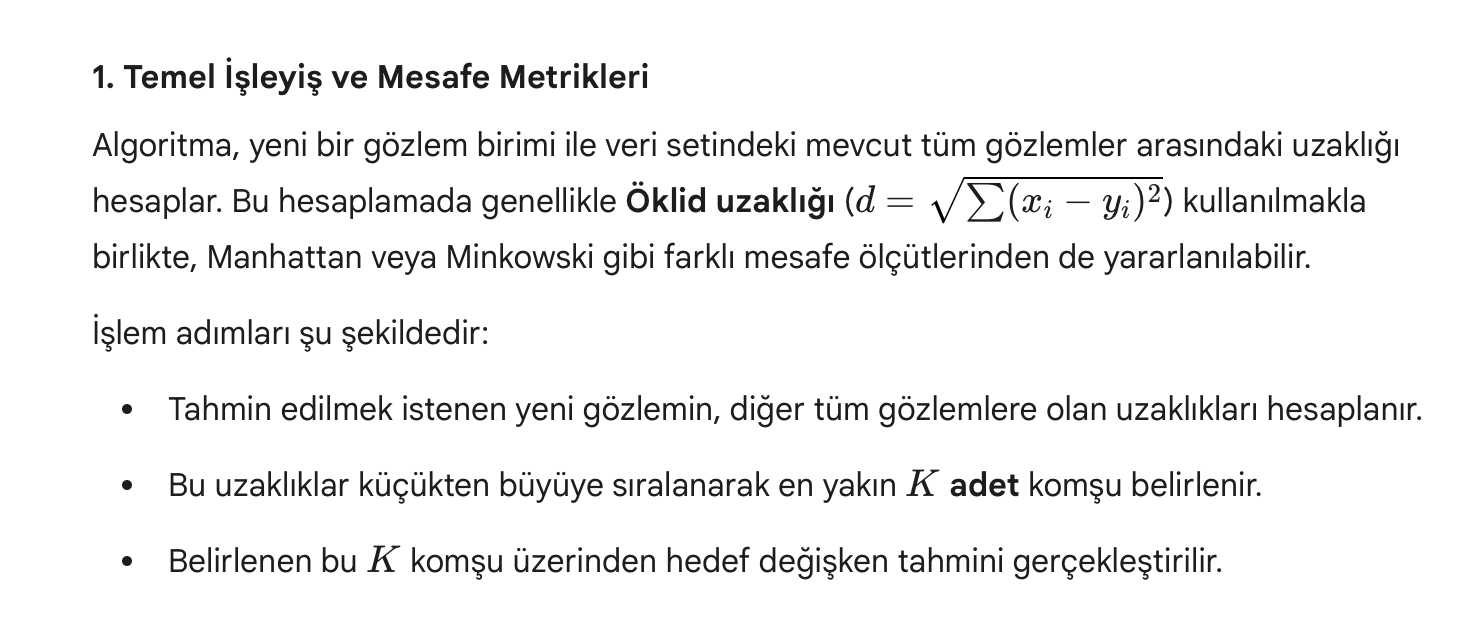



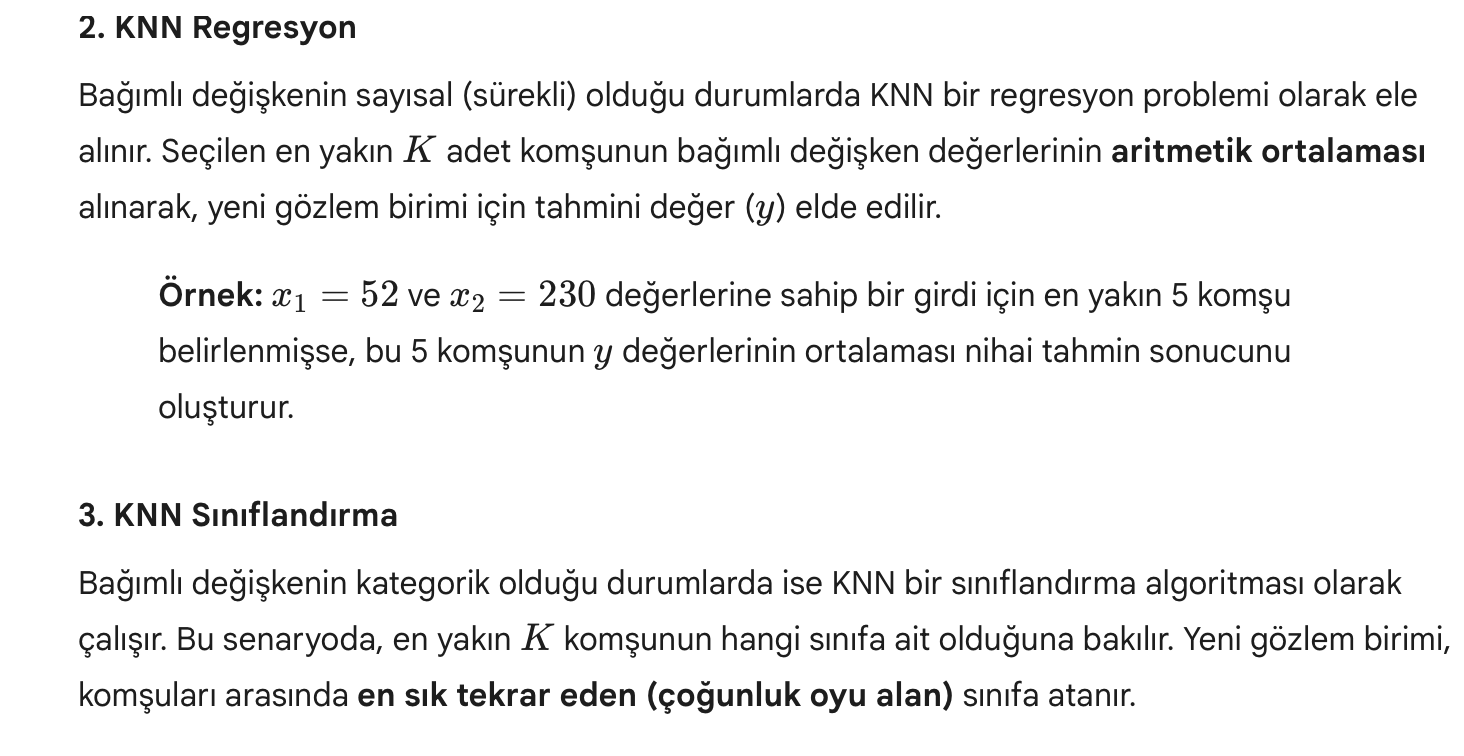

Scikit-learn kütüphanesini kullanarak K-En Yakın Komşu (KNN) algoritmasıyla bir sınıflandırma modeli oluşturuyor.

K-En Yakın Komşu (K-Nearest Neighbors - KNN) Algoritması
K-En Yakın Komşu (KNN) yöntemi, örneklemlerin birbirlerine olan benzerlikleri üzerinden tahminleme yapan, parametrik olmayan bir makine öğrenmesi algoritmasıdır. Algoritmanın temel felsefesi, "Bana arkadaşını söyle, sana kim olduğunu söyleyeyim" ilkesine dayanır; yani bir gözlem birimi, uzaydaki en yakın komşularının özelliklerine göre tanımlanır.

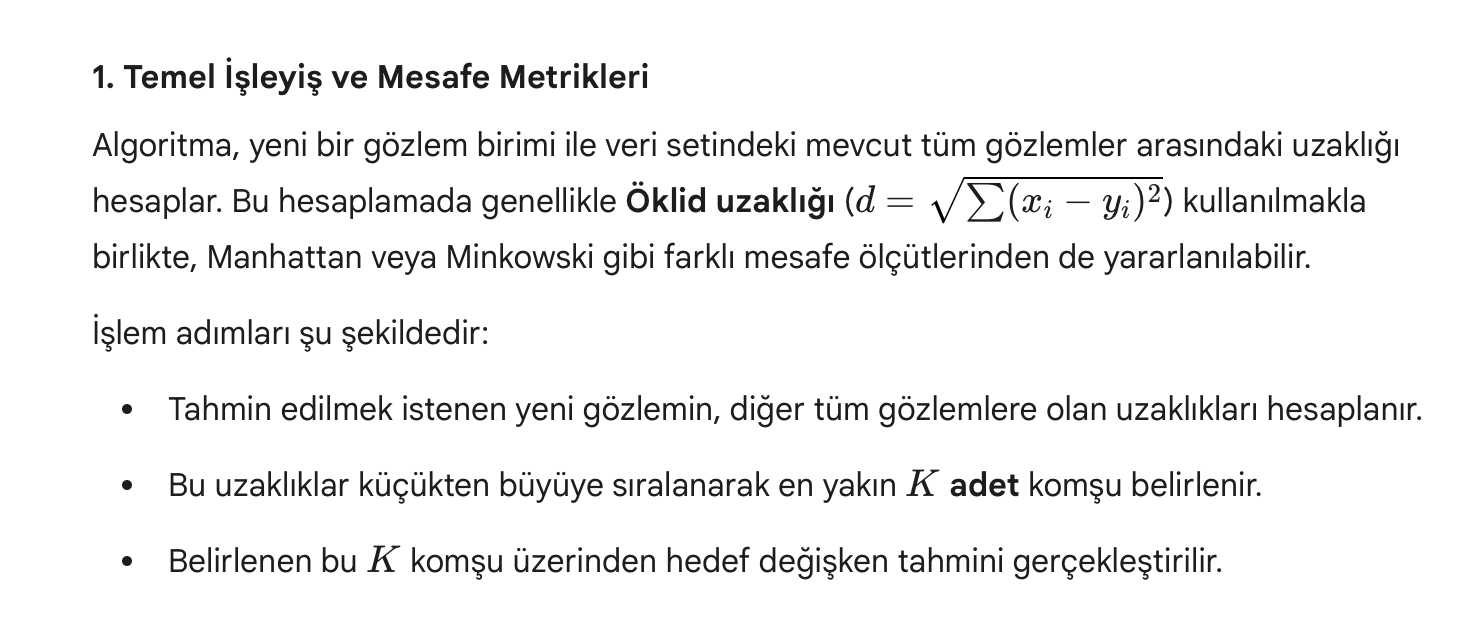



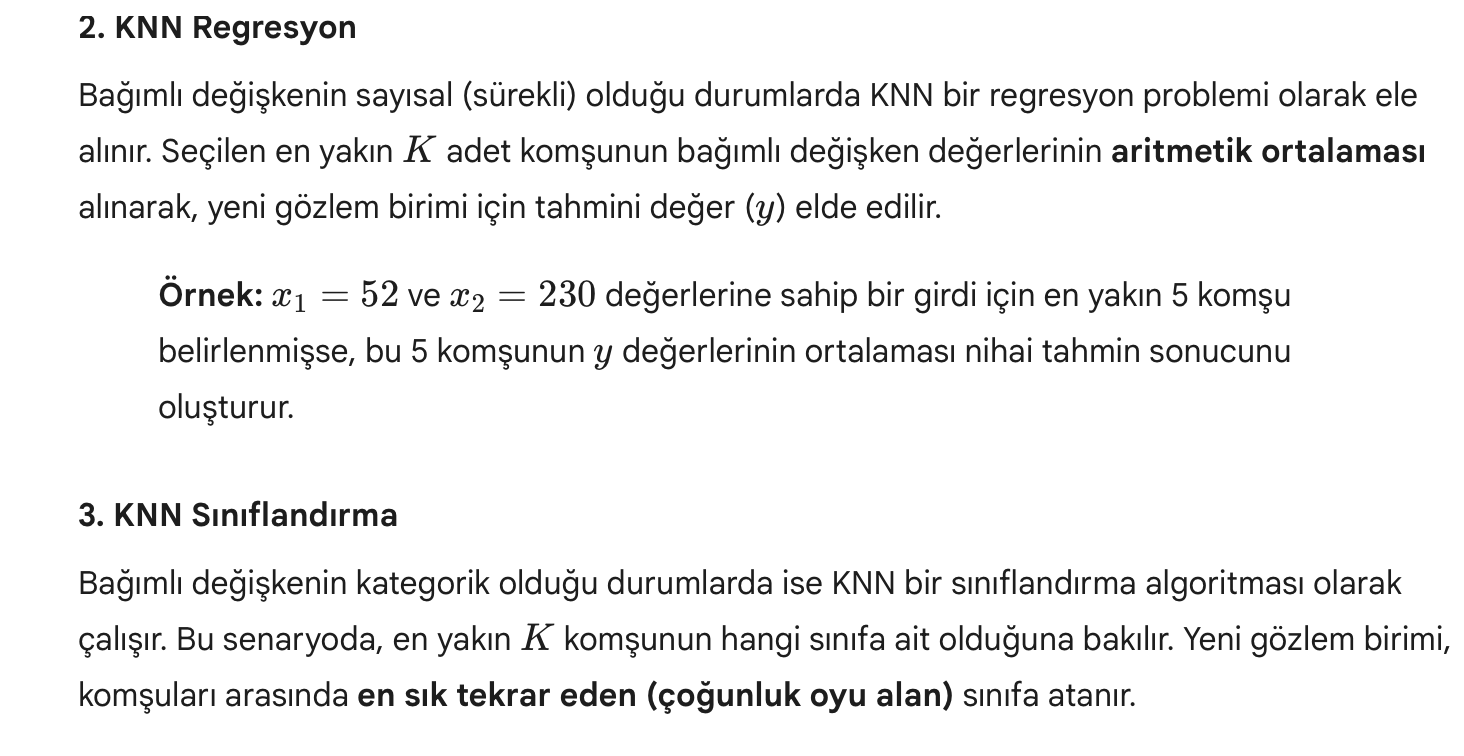

In [1]:
# sklearn: ML Library
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd

# (1) Veri Seti İncelenmesi
cancer = load_breast_cancer()
df = pd.DataFrame(data = cancer.data, columns = cancer.feature_names)
df["target"] = cancer.target

# (2) Makine Öğrenmesi Modelinin Seçilmesi - KNN Sınıflandırıcı
# (3) Modelin Train Edilmesi

X = cancer.data # features
y = cancer.target # target

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

knn = KNeighborsClassifier() # Model oluşturma komşu parametresini unutma ******
knn.fit(X_train, y_train) # fit fonksiyonu verimizi (samples + target) kullanarak knn algoritmasını eğitir

# (4) Sonuçların Değerlendirilmesi: test
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Dogruluk:", accuracy)

# (5) Hiperparametre Ayarlaması

Dogruluk: 0.9590643274853801


Kodda Dikkat Çeken Noktalar

Veri Seti: Scikit-learn'ün içinde hazır bulunan meme kanseri (breast cancer) veri seti kullanılmış.

Train-Test Split: Verinin %30'u test, %70'i eğitim için ayrılmış.

KNN Mantığı: KNeighborsClassifier() varsayılan olarak genelde 5 komşuya bakar. Görseldeki yorum satırında belirtildiği gibi, ileride bu sayıyı (n_neighbors) değiştirerek modelin başarısını artırabiliriz.

In [ ]:
# sklearn: ML Library
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# (1) Veri Seti İncelenmesi
cancer = load_breast_cancer()
df = pd.DataFrame(data = cancer.data, columns = cancer.feature_names)
df["target"] = cancer.target

# (2) Makine Öğrenmesi Modelinin Seçilmesi - KNN Sınıflandırıcı
# (3) Modelin Train Edilmesi

X = cancer.data # features
y = cancer.target # target

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# knn modeli oluştur ve train et
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train) # fit fonksiyonu verimizi (samples + target) kullanarak knn algoritmasını eğitir

# (4) Sonuçların Değerlendirilmesi: test
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Dogruluk:", accuracy)

conf_matrix = confusion_matrix(y_test, y_pred)
print("confusion_matrix:")
print(conf_matrix)

# (5) Hiperparametre Ayarlaması

Dogruluk: 0.9590643274853801
confusion_matrix:
[[ 59   4]
 [  3 105]]


Kodda Yapılan Önemli Güncellemeler:

StandardScaler: Görsellerde eklenen bu adım, KNN algoritması için çok kritiktir. Mesafe tabanlı bir algoritma olduğu için tüm özelliklerin aynı ölçekte (örneğin 0 ile 1 arası veya standart sapma bazlı) olması doğruluğu ciddi oranda artırır.

Confusion Matrix: from sklearn.metrics import confusion_matrix satırını en üste ekledim, böylece 37. satırdaki hata alma ihtimalini ortadan kaldırdık.

n_neighbors=3: İlk görselde varsayılan bırakılan komşu sayısı, sonraki görsellerde daha spesifik olması için 3 olarak güncellenmiş.

In [ ]:
from sklearn.model_selection import GridSearchCV

# (5) Hiperparametre Ayarlaması (Hyperparameter Tuning)

# Denenmesini istediğimiz parametre aralıklarını bir sözlük (dict) içinde tanımlıyoruz
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],  # Farklı komşu sayıları
    'weights': ['uniform', 'distance'],      # Ağırlıklandırma türleri
    'metric': ['euclidean', 'manhattan']     # Mesafe hesaplama yöntemleri
}

# GridSearchCV nesnesini oluşturuyoruz
# cv=5: Veriyi 5 parçaya bölüp çapraz doğrulama (Cross-Validation) yapar
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')

# Modeli tüm kombinasyonlar için eğitiyoruz
grid_search.fit(X_train, y_train)

# En iyi sonuçları yazdıralım
print("En iyi Parametreler:", grid_search.best_params_)
print("En iyi Skor (Validation):", grid_search.best_score_)

# En iyi modeli kullanarak test setinde tahmin yapalım
best_knn = grid_search.best_estimator_
y_grid_pred = best_knn.predict(X_test)

print("GridSearch sonrası Test Doğruluğu:", accuracy_score(y_test, y_grid_pred))

En iyi Parametreler: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
En iyi Skor (Validation): 0.9622151898734176
GridSearch sonrası Test Doğruluğu: 0.9590643274853801


Neden GridSearchCV Kullanıyoruz?

Otomasyon: El ile tek tek n_neighbors=3, n_neighbors=5 yazıp denemek yerine, bilgisayar bizim için tüm ihtimalleri denemesini sağlar.

Çapraz Doğrulama (Cross-Validation): Sadece tek bir eğitim setine değil, veriyi farklı parçalara bölerek test eder. Bu da modelin sadece ezberlemesini değil, gerçekten öğrenmesini sağlar.

Mesafe Metrikleri: KNN algoritmasında verilerin birbirine uzaklığı hesaplanırken kullanılan yöntemin (Euclidean veya Manhattan gibi) değişmesi, sonucu doğrudan etkileyebilir.

Küçük Bir İpucu

GridSearchCV çok fazla parametre kombinasyonu eklendiğinde işlem süresi uzayabilir. Eğer veri seti çok büyükse, daha hızlı sonuç veren RandomizedSearchCV yöntemini de denenebilir.

**Makine Öğrenmesi Süreç Yönetimi: Diyabet Veri Seti Üzerinde KNN Uygulaması**


Bu çalışma kapsamında, temel amacı bir hastanın klinik parametreleri üzerinden diyabet olup olmadığını tahmin etmek olan ikili sınıflandırma (binary classification) problemi ele alınmaktadır. Modelin merkezinde, hedef değişken olan "Outcome" (0: Sağlıklı, 1: Diyabetik) yer alırken; diğer klinik ölçümler bağımsız değişken (öznitelik) setini oluşturmaktadır.

1. Keşifçi Veri Analizi (EDA) ve Ön İşleme Stratejisi

Akademik bir modelleme sürecinde veri seti, algoritmaya sunulmadan önce kapsamlı bir incelemeden geçirilir. Bu aşama şu kritik adımları içerir:

Betimsel İstatistikler: Verinin merkezi eğilim (ortalama, medyan) ve dağılım (standart sapma, çeyreklikler) değerlerinin analizi.

Yapısal Analiz: Örneklem sayısı (768 gözlem) ve öznitelik boyutunun (9 değişken) belirlenmesi.

Sınıf Dengesi: Bağımlı değişkenin sınıflar arası dağılımının incelenmesi (Diyabetik ve Sağlıklı oranları).

Veri Temizleme: Aykırı değer (outlier) analizi, eksik veri (missing value) yönetimi ve yeni özniteliklerin türetilmesi (Feature Engineering).

2. Modelleme ve Hiperparametre Optimizasyonu

KNN algoritmasının performansı, model dışından belirlenen ve hiperparametre olarak adlandırılan parametrelere doğrudan bağlıdır. Bu süreçteki yenilikçi adım, modelin varsayılan değerlerle bırakılmayıp optimize edilmesidir:

Dışsal Parametre Yönetimi: KNN için en kritik hiperparametre olan komşuluk sayısı (K) ve mesafe metriği gibi değerlerin optimizasyonu.

Final Model Kurulumu: Belirlenen optimal hiperparametreler kullanılarak modelin yeniden eğitilmesi ve genel başarısının (Accuracy, Recall, F1-Score vb.) değerlendirilmesi.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=names)

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


Özet Bulgular

Mevcut veri seti incelendiğinde 768 gözlem birimi ve 9 değişkenli bir yapı görülmektedir. Sürecin devamında, veri önişleme adımları hızlıca tamamlanarak doğrudan KNN algoritmasının hiperparametre optimizasyonu safhasına geçilecek ve en yüksek tahmin başarısını veren nihai model inşa edilecektir.

In [ ]:
##################################################
# 1. KÜTÜPHANELERİN YÜKLENMESİ
##################################################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

##################################################
# 2. VERİ SETİNİ ÇEKME (Diyabet Verisi)
##################################################
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=names)

print(f"Veri Seti Yüklendi. Boyut: {df.shape}")

##################################################
# 3. VERİ ÖN İŞLEME (Data Preprocessing)
##################################################
# Biyolojik olarak 0 olamayacak değişkenlerdeki 0'ları NaN yapıp Medyan ile dolduruyoruz
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# Bağımlı ve Bağımsız Değişkenlerin Ayrılması
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# KNN Mesafe Tabanlı Olduğu İçin Ölçeklendirme (Standardization) Şarttır
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##################################################
# 4. HİPERPARAMETRE OPTİMİZASYONU (Grid Search)
##################################################
# En iyi K (komşu sayısı) değerini arıyoruz (1'den 50'ye kadar)
knn_params = {"n_neighbors": np.arange(1, 51)}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, knn_params, cv=10, scoring='accuracy')
knn_cv.fit(X_scaled, y)

print(f"Optimal K Değeri: {knn_cv.best_params_['n_neighbors']}")
print(f"Cross-Validation Başarı Skoru: %{knn_cv.best_score_*100:.2f}")

##################################################
# 5. FİNAL MODEL VE DEĞERLENDİRME
##################################################
knn_final = knn_cv.best_estimator_
y_pred = knn_final.predict(X_scaled)

print("\n--- Model Performans Raporu ---")
print(classification_report(y, y_pred))

Veri Seti Yüklendi. Boyut: (768, 9)
Optimal K Değeri: 36
Cross-Validation Başarı Skoru: %77.35

--- Model Performans Raporu ---
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       500
           1       0.75      0.56      0.64       268

    accuracy                           0.78       768
   macro avg       0.77      0.73      0.74       768
weighted avg       0.78      0.78      0.77       768



Veri Standartlaştırma ve Özellik Mühendisliği (Feature Engineering) Süreçleri


K-En Yakın Komşu (KNN) ve Gradyan İnişi (Gradient Descent) tabanlı algoritmaların başarısı, kullanılan bağımsız değişkenlerin ölçeklerine karşı oldukça hassastır. Bu kapsamda gerçekleştirilen işlemlerin akademik gerekçeleri ve uygulama adımları aşağıda sunulmuştur:

1. Değişken Standartlaştırma (Standardization)

Uzaklık temelli (distance-based) yöntemlerde, farklı birimlere sahip değişkenlerin (örneğin yaş ve insülin düzeyi) birbirine üstünlük sağlamaması için tüm özniteliklerin standart bir düzleme çekilmesi gerekir.

Yöntem: StandardScaler kullanılarak bağımsız değişkenler 0 ortalama ve 1 standart sapma değerine (Z-skoru normalizasyonu) dönüştürülmüştür.

Teknik Detay: fit_transform işlemi sonucunda oluşan yapı bir NumPy dizisidir (array). Verinin okunabilirliğini ve takibini sağlamak amacıyla bu dizi, orijinal sütun isimleri korunarak tekrar bir Pandas DataFrame yapısına dönüştürülmüştür.

2. Özellik Mühendisliği (Feature Engineering) ve Model Başarısı

Makine öğrenmesi modellerinin performansı sadece kullanılan algoritmaya değil, büyük oranda modelin beslendiği "özelliklerin" kalitesine bağlıdır. Andrew Ng’in de vurguladığı üzere, pratik makine öğrenmesi büyük ölçüde özellik mühendisliği üzerine kuruludur.

Yaratıcı Veri Üretimi: Literatür taraması ve domain (alan) bilgisi kullanılarak bağımsız değişkenlerden yeni kombinasyonlar türetilmesi beklenmektedir.

Etki: Standartlaştırma ve yeni değişken türetme işlemleri, modelin öğrenme hızını ve tahmin doğruluğunu (accuracy) doğrudan artıracak temel unsurlardır.

3. Veri Ön İşleme (Data Preprocessing) Stratejisi

Bu aşamada bağımsız değişkenler standartlaştırılarak analize hazır hale getirilmiştir. Akademik bir çalışma titizliğiyle, sürecin devamında şu adımlar kritik rol oynayacaktır:

Eksik ve Aykırı Değer Yönetimi: Standartlaştırma öncesi veya sonrası yapılan bu işlemler, modelin genellenebilirliğini artırır.

Iteratif Süreç: Veri ön işleme adımlarının farklı kombinasyonları denenerek model başarı skorlarındaki değişim gözlemlenmeli ve en yüksek performansı veren konfigürasyon seçilmelidir.